# Sales Correlations

Four correlation questions against the DataCo transactions file (and the clickstream log for the first one):

1. Page views vs. actual purchases, by product
2. Sales vs. profit, by region
3. Discount rate vs. profit
4. Units sold vs. profit, by category

Builds on [`0_data_overview.ipynb`](0_data_overview.ipynb). Growth-related data caveats are covered in [`0.1_company_growth.ipynb`](0.1_company_growth.ipynb) — §1 below applies the same one to the page-views join.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE, AQUA = CATEGORICAL[0], CATEGORICAL[1], CATEGORICAL[2]
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'font.size': 10,
})

def style_axis(ax, x_grid=False, y_grid=True):
    if x_grid: ax.grid(axis='x', zorder=0)
    if y_grid: ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

def pearson_r(x, y):
    return float(np.corrcoef(x, y)[0, 1])

DATA_DIR = '.'

In [ ]:
df = pd.read_csv(f'{DATA_DIR}/DataCoSupplyChainDataset.csv', encoding='latin1')
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
print(f"transactions: {df.shape[0]:,} rows")

transactions: 180,519 rows


## 1. Page views vs. actual purchases (by product)

The clickstream log only covers **Sep 2017 – Jan 2018**, and only 76 distinct products. To compare fairly, purchases are counted over that same window. Note that window overlaps the order-composition artifact flagged in `0.1_company_growth.ipynb` §2 (Oct 2017 onward) — purchase *counts* per product are still meaningful (the artifact splits orders, not product-level line counts), but keep it in mind as a caveat on absolute purchase volume.

In [ ]:
logs = pd.read_csv(f'{DATA_DIR}/tokenized_access_logs.csv', encoding='latin1')
logs['Date'] = pd.to_datetime(logs['Date'])
print(f"logs: {logs.shape[0]:,} rows, {logs['Date'].min()} -> {logs['Date'].max()}, {logs['Product'].nunique()} distinct products")

page_views = logs.groupby('Product').size().rename('page_views')

purchases = (
    df[(df['order date (DateOrders)'] >= logs['Date'].min()) & (df['order date (DateOrders)'] <= logs['Date'].max())]
    .groupby('Product Name')
    .agg(purchases=('Order Item Id', 'size'), units=('Order Item Quantity', 'sum'))
)

product_perf = page_views.to_frame().join(purchases, how='inner')
product_perf['conversion_pct'] = product_perf['purchases'] / product_perf['page_views'] * 100
print(f"{len(product_perf)} products matched by name between logs and transactions")
product_perf.sort_values('page_views', ascending=False).head(10)

logs: 469,977 rows, 2017-09-01 06:00:00 -> 2018-01-31 23:58:00, 76 distinct products
36 products matched by name between logs and transactions


,page_views,purchases,units,conversion_pct
Product,,,,
Perfect Fitness Perfect Rip Deck,27878,727,2181,2.607791
Nike Men's Dri-FIT Victory Golf Polo,25627,661,2024,2.579311
Nike Men's CJ Elite 2 TD Football Cleat,25241,691,691,2.737609
O'Brien Men's Neoprene Life Vest,16194,574,1661,3.544523
Pelican Sunstream 100 Kayak,16186,493,493,3.045842
Diamondback Women's Serene Classic Comfort Bi,15521,448,448,2.886412
Field & Stream Sportsman 16 Gun Fire Safe,15178,578,578,3.808143
Nike Men's Free 5.0+ Running Shoe,13641,398,1148,2.917675
Nike Men's Free TR 5.0 TB Training Shoe,13448,4,13,0.029744


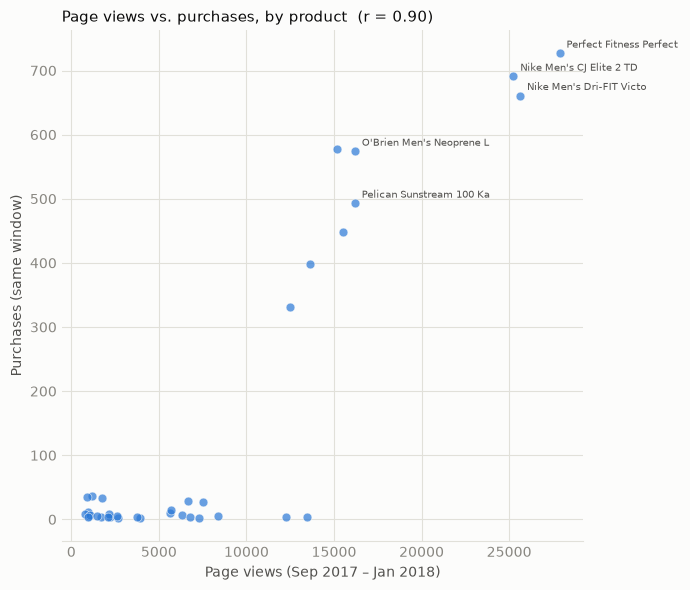

In [ ]:
r = pearson_r(product_perf['page_views'], product_perf['purchases'])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(product_perf['page_views'], product_perf['purchases'], color=BLUE, alpha=0.7, s=40, zorder=3, edgecolor=SURFACE, linewidth=0.5)
ax.set_xlabel('Page views (Sep 2017 – Jan 2018)')
ax.set_ylabel('Purchases (same window)')
ax.set_title(f'Page views vs. purchases, by product  (r = {r:.2f})', loc='left', color=INK, fontsize=11)
style_axis(ax, x_grid=True)

top = product_perf.sort_values('page_views', ascending=False).head(5)
for name, row in top.iterrows():
    ax.annotate(name[:24], (row['page_views'], row['purchases']), textcoords='offset points',
                xytext=(5, 4), fontsize=7.5, color=INK_SECONDARY)

plt.tight_layout()
plt.show()

In [ ]:
print('Top 5 by conversion rate (purchases / page views):')
product_perf.sort_values('conversion_pct', ascending=False).head(5)[['page_views', 'purchases', 'conversion_pct']]

Top 5 by conversion rate (purchases / page views):


,page_views,purchases,conversion_pct
Product,,,
Garmin Forerunner 910XT GPS Watch,877,35,3.990878
Field & Stream Sportsman 16 Gun Fire Safe,15178,578,3.808143
O'Brien Men's Neoprene Life Vest,16194,574,3.544523
Pelican Sunstream 100 Kayak,16186,493,3.045842
Garmin Approach S4 Golf GPS Watch,1190,36,3.025210


## 1.5 Data-generation artifact: excluding Oct 2017+ from here on

The page-views-vs-purchases comparison above is scoped to the clickstream log's own window (Sep 2017 – Jan 2018) because that's the only period `tokenized_access_logs.csv` covers — it's safe as-is because it compares *line-item-level* purchase counts to page views, and per-line data (not order-level aggregates) is what's unaffected by the artifact below.

Everything from here on (§2–§4) aggregates over the full order history, so it needs the same exclusion `0.1_company_growth.ipynb` §2 established: **Oct 2017 onward is a data-generation artifact** (every order collapses to 1 line item, order-level and per-order figures stop being comparable to earlier months). Dropping it before the region/discount/category cuts below keeps them consistent with `0.1`, `0.5`–`0.8`.

In [ ]:
print(f"rows before exclusion: {len(df):,}")
df = df[df['order date (DateOrders)'] < '2017-10-01'].copy()
print(f"rows after excluding Oct 2017+: {len(df):,}")

rows before exclusion: 180,519
rows after excluding Oct 2017+: 171,962


## 2. Sales vs. profit, by region

`Sales` in this dataset is `Order Item Product Price × Quantity` — the **pre-discount list price**, not what the
customer actually paid. `Order Item Total` (`Sales - Order Item Discount`) is the actual post-discount revenue, and
it's what DataCo's own `Order Item Profit Ratio` field is computed against (verified: `profit / Order Item Total`
matches `Order Item Profit Ratio` to within rounding for 96% of rows, vs. 18% for `profit / Sales`). The scatter below
keeps `Sales` on the x-axis (it's a reasonable proxy for market size, not a margin claim), but the margin table uses
`Order Item Total` as the denominator so it isn't systematically understated.

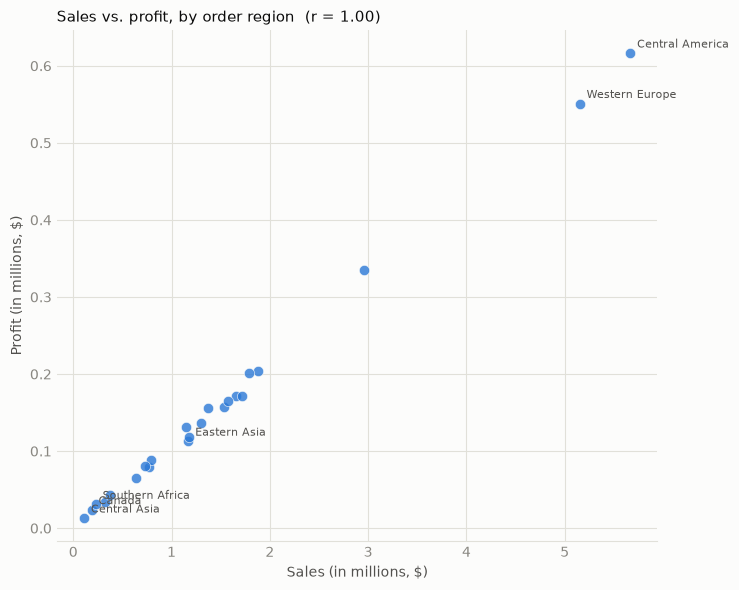

In [ ]:
region_perf = df.groupby('Order Region').agg(
    sales=('Sales', 'sum'),
    revenue=('Order Item Total', 'sum'),
    profit=('Order Profit Per Order', 'sum'),
).reset_index()
region_perf['sales_m'] = region_perf['sales'] / 1e6
region_perf['revenue_m'] = region_perf['revenue'] / 1e6
region_perf['profit_m'] = region_perf['profit'] / 1e6
region_perf['margin_pct'] = region_perf['profit'] / region_perf['revenue'] * 100

r = pearson_r(region_perf['sales'], region_perf['profit'])

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(region_perf['sales_m'], region_perf['profit_m'], color=BLUE, alpha=0.8, s=55, zorder=3, edgecolor=SURFACE, linewidth=0.5)
ax.set_xlabel('Sales (in millions, $)')
ax.set_ylabel('Profit (in millions, $)')
ax.set_title(f'Sales vs. profit, by order region  (r = {r:.2f})', loc='left', color=INK, fontsize=11)
style_axis(ax, x_grid=True)

to_label = pd.concat([
    region_perf.nlargest(2, 'sales_m'),
    region_perf.nsmallest(2, 'sales_m'),
    region_perf.nlargest(1, 'margin_pct'),
    region_perf.nsmallest(1, 'margin_pct'),
]).drop_duplicates('Order Region')
for _, row in to_label.iterrows():
    ax.annotate(row['Order Region'], (row['sales_m'], row['profit_m']), textcoords='offset points',
                xytext=(5, 4), fontsize=8, color=INK_SECONDARY)

plt.tight_layout()
plt.show()

In [ ]:
print('Regions ranked by margin (profit / Order Item Total):')
region_perf.sort_values('margin_pct')[['Order Region', 'sales_m', 'revenue_m', 'profit_m', 'margin_pct']]

Regions ranked by margin (profit / Order Item Total):


,Order Region,sales_m,revenue_m,profit_m,margin_pct
7,Eastern Asia,1.170048,1.051096,0.112746,10.726518
11,Oceania,1.720379,1.543580,0.171873,11.134684
20,West Asia,1.174672,1.056081,0.118815,11.250596
9,North Africa,0.634752,0.572242,0.064600,11.288906
15,Southeast Asia,1.538177,1.384309,0.157185,11.354734
2,Central Africa,0.327263,0.292913,0.033447,11.418858
8,Eastern Europe,0.774267,0.696307,0.079717,11.448546
1,Caribbean,1.651019,1.481669,0.171826,11.596765
13,South Asia,1.299776,1.168309,0.135980,11.639064
21,West of USA,1.571416,1.412254,0.164941,11.679252


Reading this table as a scorecard also runs into the region-rotation artifact (`0.5_by_region_analysis.ipynb` §2, `0.7_region_activity_gaps.ipynb`): 19 of 23 regions were only ever "switched on" for a 5–18 month block, not the full Jan 2015–Sep 2017 window used here, so a low-margin or low-revenue region here may just mean fewer active months, not weaker performance. Treat this as a correlation illustration, not a per-region verdict — see `0.5`/`0.7` for a fair region-by-region read.

## 3. Discount rate vs. profit

180K order lines is too dense for a readable scatter, so discount rate is bucketed into 5-point bands and averaged.

Pearson r (raw, order-line level): discount rate vs. profit ratio = -0.002


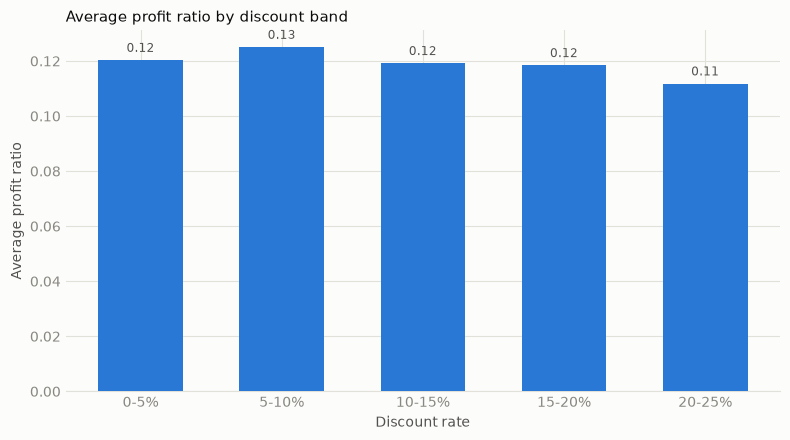

In [ ]:
df['discount_bucket'] = pd.cut(df['Order Item Discount Rate'], bins=np.arange(0, 0.30, 0.05),
                                include_lowest=True, right=False)

r = pearson_r(df['Order Item Discount Rate'], df['Order Item Profit Ratio'])
print(f'Pearson r (raw, order-line level): discount rate vs. profit ratio = {r:.3f}')

bucket_perf = df.groupby('discount_bucket', observed=True).agg(
    avg_profit_ratio=('Order Item Profit Ratio', 'mean'),
    n=('Order Item Id', 'size'),
)
bucket_labels = [f'{int(iv.left*100)}-{int(iv.right*100)}%' for iv in bucket_perf.index]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(bucket_labels, bucket_perf['avg_profit_ratio'], color=BLUE, width=0.6, zorder=3)
ax.set_xlabel('Discount rate')
ax.set_ylabel('Average profit ratio')
ax.set_title('Average profit ratio by discount band', loc='left', color=INK, fontsize=11)
style_axis(ax)
for bar, v in zip(bars, bucket_perf['avg_profit_ratio']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.2f}', ha='center', color=INK_SECONDARY, fontsize=8.5)
plt.tight_layout()
plt.show()

## 4. Units sold vs. profit, by category

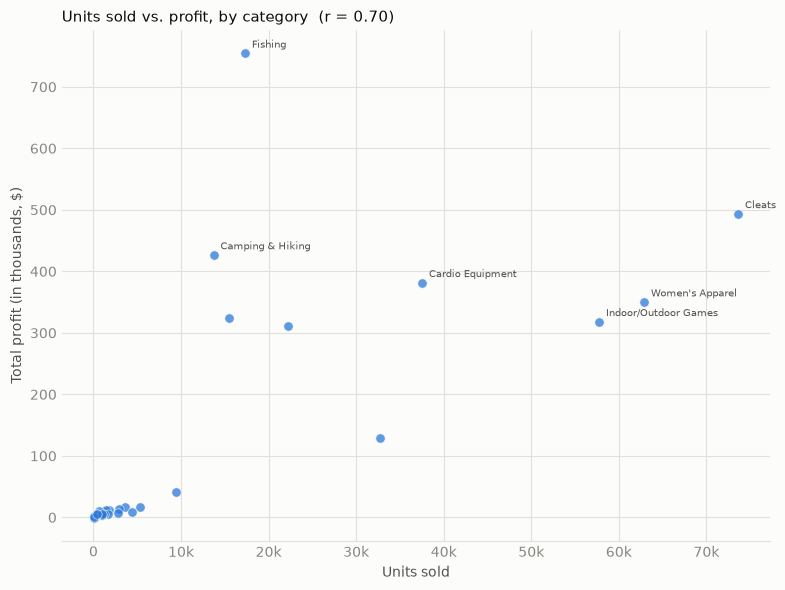

In [ ]:
cat_perf = df.groupby('Category Name').agg(
    units=('Order Item Quantity', 'sum'),
    profit=('Order Profit Per Order', 'sum'),
).reset_index()
cat_perf['profit_k'] = cat_perf['profit'] / 1e3

r = pearson_r(cat_perf['units'], cat_perf['profit'])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cat_perf['units'], cat_perf['profit_k'], color=BLUE, alpha=0.75, s=45, zorder=3, edgecolor=SURFACE, linewidth=0.5)
ax.set_xlabel('Units sold')
ax.set_ylabel('Total profit (in thousands, $)')
ax.set_title(f'Units sold vs. profit, by category  (r = {r:.2f})', loc='left', color=INK, fontsize=11)
style_axis(ax, x_grid=True)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:,.0f}k' if v >= 1000 else f'{v:,.0f}'))

top = pd.concat([cat_perf.nlargest(4, 'units'), cat_perf.nlargest(4, 'profit_k')]).drop_duplicates('Category Name')
for _, row in top.iterrows():
    ax.annotate(row['Category Name'][:22], (row['units'], row['profit_k']), textcoords='offset points',
                xytext=(5, 4), fontsize=7.5, color=INK_SECONDARY)

plt.tight_layout()
plt.show()

## Takeaways

- **Page views vs. purchases**: printed *r* above (see cell output) is the correlation across the 72 matched products — check whether high-traffic products are converting, or whether traffic and purchases are driven by different products entirely (low conversion-rate products are worth a merchandising look).
- **Sales vs. profit by region**: strong positive correlation is expected (bigger markets produce more absolute profit), but the margin-ranked table separates *volume* leaders from *efficiency* leaders — a region can be sales-heavy and margin-weak at the same time. Margin is `profit / Order Item Total` (actual post-discount revenue), not `profit / Sales` (pre-discount list price) — the latter would understate margin and more so for heavily-discounted regions.
- **Discount vs. profit**: compare the raw order-line correlation to the bucketed bar chart — a weak raw *r* can still hide a real threshold effect visible once discount is binned.
- **Units sold vs. profit by category**: high-volume categories aren't automatically the most profitable ones; the annotated outliers are the categories worth checking first for pricing/margin issues.